# QUI EMPRUNTE QUOI ?

## Feuille de route
* Gros emprunteurs ou petits emprunteurs ?
* Emprunteurs réguliers ou emprunteurs ponctuels ?
* Quel usage des collections par âge ? (les + et les - empruntées, filtre 10 ccodes)
* Courbe de Lawrance : concentration des prêts

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
import datetime

from kiblib.utils.db import DbConn
#from kiblib.utils import lucas_sns_params

In [2]:
query = "SELECT * FROM statdb.stat_issues WHERE YEAR(issuedate)='2025'"

In [3]:
db_conn = DbConn().create_engine()
issues = pd.read_sql(query,con=db_conn)

In [4]:
issues['année'] = pd.DatetimeIndex(issues['issuedate']).year

In [5]:
issues['nb'] = 1

In [6]:
issues

,issuedate,date_due,returndate,renewals,branch,arret_bus,borrowernumber,cardnumber,age,sexe,...,publicationyear,biblionumber,dateaccessioned,cle,timestamp,issue_id,returnbranch,statut_retour,année,nb
0,2025-01-02 08:51:15,2025-02-22 23:59:00,2025-01-14 08:44:56,0,MED,None,668,X61,64,M,...,2024,370947.0,2024-12-07,2025-01-02 08:51:15-487483,2025-10-25 11:28:08,5190414,None,1,2025,1
1,2025-01-02 09:18:05,2025-02-28 23:59:00,2025-01-07 09:59:09,0,MED,None,668,X61,64,M,...,2024,368381.0,2024-09-07,2025-01-02 09:18:05-482896,2025-01-08 03:12:42,5190415,None,1,2025,1
2,2025-01-02 09:27:54,2025-01-23 23:59:00,2025-01-09 13:41:59,0,MED,None,69175,X0002591124,59,M,...,2020,332180.0,2020-12-11,2025-01-02 09:27:54-419188,2025-01-10 03:13:54,5190416,None,1,2025,1
3,2025-01-02 09:40:52,2025-01-23 23:59:00,2025-01-03 10:09:58,0,MED,None,20586,X0000202000,54,F,...,2024,369018.0,2024-10-16,2025-01-02 09:40:52-484368,2025-01-04 03:11:36,5190417,None,1,2025,1
4,2025-01-02 09:42:21,2025-02-04 23:59:00,2025-02-05 10:11:31,0,MED,None,74390,X0002611402,NP,N,...,2009,278063.0,2015-07-03,2025-01-02 09:42:21-324799,2025-02-06 03:11:52,5190418,None,1,2025,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309541,2025-11-16 15:07:09,2025-12-07 23:59:00,2025-11-16 15:23:42,0,MED,None,16438,X0002055381,55,F,...,2021,361580.0,2023-12-23,2025-11-16 15:07:09-471637,2025-11-18 03:14:29,5630178,None,1,2025,1
309542,2025-11-16 15:08:19,2025-12-28 23:59:00,2025-11-16 15:29:55,1,MED,None,16438,X0002055381,55,F,...,2024,365595.0,2024-06-04,2025-11-16 15:08:19-479093,2025-11-18 03:14:29,5630179,None,1,2025,1
309543,2025-11-16 15:58:44,2025-12-28 23:59:00,2025-11-16 16:06:59,1,MED,None,84458,X0002794976,36,M,...,2019,342529.0,2021-12-28,2025-11-16 15:58:44-437637,2025-11-18 03:14:29,5630180,None,1,2025,1
309544,2025-11-16 16:37:50,2025-12-07 23:59:00,2025-11-16 16:53:56,0,MED,None,44505,X0002195872,9,M,...,2022,348571.0,2022-07-15,2025-11-16 16:37:50-446979,2025-11-18 03:14:29,5630181,None,1,2025,1


In [7]:
# 2 méthodes pour faire la même chose

#Avec transform
issues['nb docs empruntés pour cet emprunteur'] = issues.groupby('borrowernumber')['borrowernumber'].transform('count')


# Avec map + valuecounts()
issues['nb docs empruntés pour cet emprunteur 2'] = issues['borrowernumber'].map(issues['borrowernumber'].value_counts())

In [8]:
issues

,issuedate,date_due,returndate,renewals,branch,arret_bus,borrowernumber,cardnumber,age,sexe,...,dateaccessioned,cle,timestamp,issue_id,returnbranch,statut_retour,année,nb,nb docs empruntés pour cet emprunteur,nb docs empruntés pour cet emprunteur 2
0,2025-01-02 08:51:15,2025-02-22 23:59:00,2025-01-14 08:44:56,0,MED,None,668,X61,64,M,...,2024-12-07,2025-01-02 08:51:15-487483,2025-10-25 11:28:08,5190414,None,1,2025,1,40,40
1,2025-01-02 09:18:05,2025-02-28 23:59:00,2025-01-07 09:59:09,0,MED,None,668,X61,64,M,...,2024-09-07,2025-01-02 09:18:05-482896,2025-01-08 03:12:42,5190415,None,1,2025,1,40,40
2,2025-01-02 09:27:54,2025-01-23 23:59:00,2025-01-09 13:41:59,0,MED,None,69175,X0002591124,59,M,...,2020-12-11,2025-01-02 09:27:54-419188,2025-01-10 03:13:54,5190416,None,1,2025,1,190,190
3,2025-01-02 09:40:52,2025-01-23 23:59:00,2025-01-03 10:09:58,0,MED,None,20586,X0000202000,54,F,...,2024-10-16,2025-01-02 09:40:52-484368,2025-01-04 03:11:36,5190417,None,1,2025,1,144,144
4,2025-01-02 09:42:21,2025-02-04 23:59:00,2025-02-05 10:11:31,0,MED,None,74390,X0002611402,NP,N,...,2015-07-03,2025-01-02 09:42:21-324799,2025-02-06 03:11:52,5190418,None,1,2025,1,83,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309541,2025-11-16 15:07:09,2025-12-07 23:59:00,2025-11-16 15:23:42,0,MED,None,16438,X0002055381,55,F,...,2023-12-23,2025-11-16 15:07:09-471637,2025-11-18 03:14:29,5630178,None,1,2025,1,65,65
309542,2025-11-16 15:08:19,2025-12-28 23:59:00,2025-11-16 15:29:55,1,MED,None,16438,X0002055381,55,F,...,2024-06-04,2025-11-16 15:08:19-479093,2025-11-18 03:14:29,5630179,None,1,2025,1,65,65
309543,2025-11-16 15:58:44,2025-12-28 23:59:00,2025-11-16 16:06:59,1,MED,None,84458,X0002794976,36,M,...,2021-12-28,2025-11-16 15:58:44-437637,2025-11-18 03:14:29,5630180,None,1,2025,1,55,55
309544,2025-11-16 16:37:50,2025-12-07 23:59:00,2025-11-16 16:53:56,0,MED,None,44505,X0002195872,9,M,...,2022-07-15,2025-11-16 16:37:50-446979,2025-11-18 03:14:29,5630181,None,1,2025,1,71,71


In [9]:
issues['nb personnes ayant emprunté ce nombre de livre en 2025'] = issues['nb docs empruntés pour cet emprunteur'].map(issues['nb docs empruntés pour cet emprunteur'].value_counts())

In [10]:
issues_dist = issues.drop_duplicates(subset=['borrowernumber'],keep='first')

In [11]:
issues_dist

,issuedate,date_due,returndate,renewals,branch,arret_bus,borrowernumber,cardnumber,age,sexe,...,cle,timestamp,issue_id,returnbranch,statut_retour,année,nb,nb docs empruntés pour cet emprunteur,nb docs empruntés pour cet emprunteur 2,nb personnes ayant emprunté ce nombre de livre en 2025
0,2025-01-02 08:51:15,2025-02-22 23:59:00,2025-01-14 08:44:56,0,MED,None,668,X61,64,M,...,2025-01-02 08:51:15-487483,2025-10-25 11:28:08,5190414,None,1,2025,1,40,40,2720
2,2025-01-02 09:27:54,2025-01-23 23:59:00,2025-01-09 13:41:59,0,MED,None,69175,X0002591124,59,M,...,2025-01-02 09:27:54-419188,2025-01-10 03:13:54,5190416,None,1,2025,1,190,190,950
3,2025-01-02 09:40:52,2025-01-23 23:59:00,2025-01-03 10:09:58,0,MED,None,20586,X0000202000,54,F,...,2025-01-02 09:40:52-484368,2025-01-04 03:11:36,5190417,None,1,2025,1,144,144,576
4,2025-01-02 09:42:21,2025-02-04 23:59:00,2025-02-05 10:11:31,0,MED,None,74390,X0002611402,NP,N,...,2025-01-02 09:42:21-324799,2025-02-06 03:11:52,5190418,None,1,2025,1,83,83,1079
6,2025-01-02 09:45:47,2025-01-23 23:59:00,2025-01-09 15:36:31,0,MED,None,9572,X0002555904,76,M,...,2025-01-02 09:45:47-383954,2025-01-10 03:13:54,5190420,None,1,2025,1,10,10,4310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309387,2025-11-16 17:27:25,2025-12-07 23:59:00,NaT,0,MED,None,28626,X0002297354,22,F,...,2025-11-16 17:27:25-492836,2025-11-18 03:14:29,5629936,None,1,2025,1,1,1,929
309398,2025-11-16 17:28:09,2025-12-07 23:59:00,NaT,0,MED,None,88110,X0002858500,7,F,...,2025-11-16 17:28:09-447632,2025-11-18 03:14:29,5629947,None,1,2025,1,7,7,2541
309489,2025-11-16 17:50:15,2025-12-07 23:59:00,NaT,0,MED,None,65275,X0002517216,6,M,...,2025-11-16 17:50:15-460863,2025-11-18 03:14:29,5630038,None,1,2025,1,3,3,1974
309520,2025-11-16 17:56:12,2025-12-07 23:59:00,NaT,0,MED,None,76935,X0002705712,28,F,...,2025-11-16 17:56:12-456267,2025-11-18 03:14:29,5630069,None,1,2025,1,3,3,1974


In [12]:
issues_dist = issues_dist.groupby('nb docs empruntés pour cet emprunteur')['nb personnes ayant emprunté ce nombre de livre en 2025'].size().to_frame().reset_index()

In [13]:
issues_dist['volume docs empruntés'] = issues_dist['nb docs empruntés pour cet emprunteur'] * issues_dist['nb personnes ayant emprunté ce nombre de livre en 2025']

In [14]:
issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=1)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=10),
                'nb docs empruntés label'
               ] = 'a/ Entre 1 et 10 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=11)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=20),
                'nb docs empruntés label',
               ] = 'b/ Entre 11 et 20 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=21)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=40),
                'nb docs empruntés label',
               ] = 'c/ Entre 21 et 40 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=41)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=60),
                'nb docs empruntés label',
               ] = 'd/ Entre 41 et 60 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=61)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=80),
                'nb docs empruntés label',
               ] = 'e/ Entre 61 et 80 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=81)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=100),
                'nb docs empruntés label',
               ] = 'f/ Entre 81 et 100 \ndocs empruntés'



issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=101)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=120),
                'nb docs empruntés label',
               ] = 'g/ Entre 101 et 120 \ndocs empruntés'



issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=121)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=140),
                'nb docs empruntés label',
               ] = 'h/ Entre 121 et 140 \ndocs empruntés'

issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=141)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=160),
                'nb docs empruntés label',
               ] = 'i/ Entre 141 et 160 \ndocs empruntés'

issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=161)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=180),
                'nb docs empruntés label',
               ] = 'j/ Entre 161 et 180 \ndocs empruntés'


issues_dist.loc[(issues_dist['nb docs empruntés pour cet emprunteur']>=181)&
                (issues_dist['nb docs empruntés pour cet emprunteur']<=200),
                'nb docs empruntés label',
               ] = 'k/ Entre 181 et 200 \ndocs empruntés'


issues_dist.loc[issues_dist['nb docs empruntés pour cet emprunteur']>=200,
                'nb docs empruntés label',
               ] = 'x/ Plus de 200 \ndocs empruntés'

In [15]:
issues_dist

,nb docs empruntés pour cet emprunteur,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,nb docs empruntés label
0,1,929,929,a/ Entre 1 et 10 \ndocs empruntés
1,2,768,1536,a/ Entre 1 et 10 \ndocs empruntés
2,3,658,1974,a/ Entre 1 et 10 \ndocs empruntés
3,4,568,2272,a/ Entre 1 et 10 \ndocs empruntés
4,5,450,2250,a/ Entre 1 et 10 \ndocs empruntés
...,...,...,...,...
283,582,1,582,x/ Plus de 200 \ndocs empruntés
284,627,1,627,x/ Plus de 200 \ndocs empruntés
285,658,1,658,x/ Plus de 200 \ndocs empruntés
286,691,1,691,x/ Plus de 200 \ndocs empruntés


In [16]:
issues_dist

,nb docs empruntés pour cet emprunteur,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,nb docs empruntés label
0,1,929,929,a/ Entre 1 et 10 \ndocs empruntés
1,2,768,1536,a/ Entre 1 et 10 \ndocs empruntés
2,3,658,1974,a/ Entre 1 et 10 \ndocs empruntés
3,4,568,2272,a/ Entre 1 et 10 \ndocs empruntés
4,5,450,2250,a/ Entre 1 et 10 \ndocs empruntés
...,...,...,...,...
283,582,1,582,x/ Plus de 200 \ndocs empruntés
284,627,1,627,x/ Plus de 200 \ndocs empruntés
285,658,1,658,x/ Plus de 200 \ndocs empruntés
286,691,1,691,x/ Plus de 200 \ndocs empruntés


In [17]:
issues_dist_2 = issues_dist.pivot_table(index='nb docs empruntés label',
                                       values=['nb personnes ayant emprunté ce nombre de livre en 2025',
                                               'volume docs empruntés'],
                                       aggfunc=sum
                                      )

In [18]:
issues_dist_2['% personnes ayant emprunté ce nombre de docs en 2025'] = issues_dist_2['nb personnes ayant emprunté ce nombre de livre en 2025'] / issues_dist_2['nb personnes ayant emprunté ce nombre de livre en 2025'].sum()*100

In [19]:
issues_dist_2

,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,% personnes ayant emprunté ce nombre de docs en 2025
nb docs empruntés label,,,
a/ Entre 1 et 10 \ndocs empruntés,5226,23689,47.887840
b/ Entre 11 et 20 \ndocs empruntés,1791,27274,16.411619
c/ Entre 21 et 40 \ndocs empruntés,1662,48616,15.229543
d/ Entre 41 et 60 \ndocs empruntés,812,40117,7.440667
e/ Entre 61 et 80 \ndocs empruntés,497,34609,4.554201
f/ Entre 81 et 100 \ndocs empruntés,286,25737,2.620728
g/ Entre 101 et 120 \ndocs empruntés,195,21294,1.786860
h/ Entre 121 et 140 \ndocs empruntés,122,15831,1.117933
i/ Entre 141 et 160 \ndocs empruntés,83,12350,0.760561


In [20]:
issues_dist_2['% cumulé personnes ayant emprunté ce nombre de docs en 2025'] = issues_dist_2['% personnes ayant emprunté ce nombre de docs en 2025'].cumsum()

In [21]:
issues_dist_2

,nb personnes ayant emprunté ce nombre de livre en 2025,volume docs empruntés,% personnes ayant emprunté ce nombre de docs en 2025,% cumulé personnes ayant emprunté ce nombre de docs en 2025
nb docs empruntés label,,,,
a/ Entre 1 et 10 \ndocs empruntés,5226,23689,47.887840,47.887840
b/ Entre 11 et 20 \ndocs empruntés,1791,27274,16.411619,64.299459
c/ Entre 21 et 40 \ndocs empruntés,1662,48616,15.229543,79.529002
d/ Entre 41 et 60 \ndocs empruntés,812,40117,7.440667,86.969669
e/ Entre 61 et 80 \ndocs empruntés,497,34609,4.554201,91.523871
f/ Entre 81 et 100 \ndocs empruntés,286,25737,2.620728,94.144598
g/ Entre 101 et 120 \ndocs empruntés,195,21294,1.786860,95.931458
h/ Entre 121 et 140 \ndocs empruntés,122,15831,1.117933,97.049391
i/ Entre 141 et 160 \ndocs empruntés,83,12350,0.760561,97.809951


In [22]:
issues_dist_2.columns

Index(['nb personnes ayant emprunté ce nombre de livre en 2025',
       'volume docs empruntés',
       '% personnes ayant emprunté ce nombre de docs en 2025',
       '% cumulé personnes ayant emprunté ce nombre de docs en 2025'],
      dtype='object')

In [23]:
issues_dist_2["% cumulé personnes ayant emprunté ce nombre de docs en 2025"]

nb docs empruntés label
a/ Entre 1 et 10 \ndocs empruntés        47.887840
b/ Entre 11 et 20 \ndocs empruntés       64.299459
c/ Entre 21 et 40 \ndocs empruntés       79.529002
d/ Entre 41 et 60 \ndocs empruntés       86.969669
e/ Entre 61 et 80 \ndocs empruntés       91.523871
f/ Entre 81 et 100 \ndocs empruntés      94.144598
g/ Entre 101 et 120 \ndocs empruntés     95.931458
h/ Entre 121 et 140 \ndocs empruntés     97.049391
i/ Entre 141 et 160 \ndocs empruntés     97.809951
j/ Entre 161 et 180 \ndocs empruntés     98.332264
k/ Entre 181 et 200 \ndocs empruntés     98.689636
x/ Plus de 200 \ndocs empruntés         100.000000
Name: % cumulé personnes ayant emprunté ce nombre de docs en 2025, dtype: float64

> NOTE : le graphique ci-dessous se li de gauche à droite, les chiffres sont cumulés.  

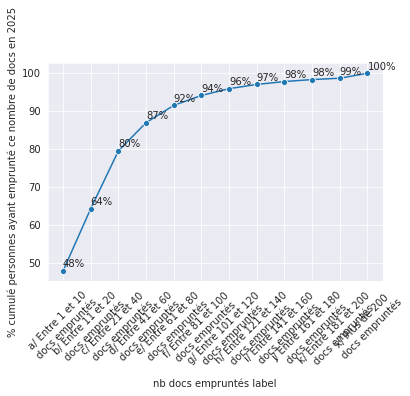

In [24]:
f,ax = plt.subplots(nrows=1,ncols=1)

ax = sns.lineplot(data=issues_dist_2,
             x=issues_dist_2.index,
             y='% cumulé personnes ayant emprunté ce nombre de docs en 2025',
             #ax=ax[1],
             marker='o',
           )

for x,y in zip(issues_dist_2.index,issues_dist_2['% cumulé personnes ayant emprunté ce nombre de docs en 2025']):
    plt.text(x=x,y=y+1,s = '{:.0f}'.format(y) + '%')

ax.tick_params(axis='x',rotation=45)

In [173]:
issues

,issuedate,date_due,returndate,renewals,branch,arret_bus,borrowernumber,cardnumber,age,sexe,...,timestamp,issue_id,returnbranch,statut_retour,année,nb,nb docs empruntés pour cet emprunteur,nb docs empruntés pour cet emprunteur 2,nb personnes ayant emprunté ce nombre de livre en 2025,nb_prets
0,2025-01-02 08:51:15,2025-02-22 23:59:00,2025-01-14 08:44:56,0,MED,None,668,X61,64,M,...,2025-10-25 11:28:08,5190414,None,1,2025,1,40,40,2720,1
1,2025-01-02 09:18:05,2025-02-28 23:59:00,2025-01-07 09:59:09,0,MED,None,668,X61,64,M,...,2025-01-08 03:12:42,5190415,None,1,2025,1,40,40,2720,1
2,2025-01-02 09:27:54,2025-01-23 23:59:00,2025-01-09 13:41:59,0,MED,None,69175,X0002591124,59,M,...,2025-01-10 03:13:54,5190416,None,1,2025,1,190,190,950,1
3,2025-01-02 09:40:52,2025-01-23 23:59:00,2025-01-03 10:09:58,0,MED,None,20586,X0000202000,54,F,...,2025-01-04 03:11:36,5190417,None,1,2025,1,144,144,576,1
4,2025-01-02 09:42:21,2025-02-04 23:59:00,2025-02-05 10:11:31,0,MED,None,74390,X0002611402,NP,N,...,2025-02-06 03:11:52,5190418,None,1,2025,1,83,83,1079,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309541,2025-11-16 15:07:09,2025-12-07 23:59:00,2025-11-16 15:23:42,0,MED,None,16438,X0002055381,55,F,...,2025-11-18 03:14:29,5630178,None,1,2025,1,65,65,2145,1
309542,2025-11-16 15:08:19,2025-12-28 23:59:00,2025-11-16 15:29:55,1,MED,None,16438,X0002055381,55,F,...,2025-11-18 03:14:29,5630179,None,1,2025,1,65,65,2145,1
309543,2025-11-16 15:58:44,2025-12-28 23:59:00,2025-11-16 16:06:59,1,MED,None,84458,X0002794976,36,M,...,2025-11-18 03:14:29,5630180,None,1,2025,1,55,55,2255,1
309544,2025-11-16 16:37:50,2025-12-07 23:59:00,2025-11-16 16:53:56,0,MED,None,44505,X0002195872,9,M,...,2025-11-18 03:14:29,5630181,None,1,2025,1,71,71,1988,1


In [174]:
issues.groupby('categorycode').size()

categorycode
BIBL    212490
CLAS     17259
COLI      2535
COLS      2557
CSLT         3
CSVT      7944
ECOL      7252
MEDA     15819
MEDB     15671
MEDC     19194
MEDP      8822
dtype: int64

In [175]:
cartes_individuelles = ['BIBL','CSLT','CSVT','MEDA','MEDB','MEDC','MEDP']
issues['nb_prets'] = 1
prets = issues[issues['categorycode'].isin(cartes_individuelles)]
prets = issues.pivot_table(index='borrowernumber',values='nb_prets',aggfunc=sum)

In [176]:
prets

,nb_prets
borrowernumber,
73,1
81,31
82,7
103,27
146,45
...,...
88647,6
88650,7
88651,8


In [177]:
prets_reset = prets.reset_index()

In [178]:
prets_reset = prets_reset.groupby('nb_prets')['borrowernumber'].count().to_frame()

In [179]:
prets_reset = prets_reset.rename(columns={'borrowernumber':'nb_adherents'})

In [180]:
total_adherents = prets_reset['nb_adherents'].sum()

In [181]:
prets_reset['F_adherents'] = prets_reset['nb_adherents'].cumsum()
prets_reset['%_cumulé_adherents'] = round(prets_reset['F_adherents']/total_adherents*100,2)

In [182]:
prets_reset

,nb_adherents,F_adherents,%_cumulé_adherents
nb_prets,,,
1,929,929,8.51
2,768,1697,15.55
3,658,2355,21.58
4,568,2923,26.78
5,450,3373,30.91
...,...,...,...
582,1,10909,99.96
627,1,10910,99.97
658,1,10911,99.98


In [183]:
prets_reset = prets_reset.reset_index()

In [184]:
prets_reset = prets_reset[['nb_adherents','F_adherents','%_cumulé_adherents','nb_prets']]
prets_reset

,nb_adherents,F_adherents,%_cumulé_adherents,nb_prets
0,929,929,8.51,1
1,768,1697,15.55,2
2,658,2355,21.58,3
3,568,2923,26.78,4
4,450,3373,30.91,5
...,...,...,...,...
283,1,10909,99.96,582
284,1,10910,99.97,627
285,1,10911,99.98,658
286,1,10912,99.99,691


In [185]:
prets_reset['nb_prets_total'] = prets_reset['nb_prets'] * prets_reset['nb_adherents']

In [186]:
prets_reset['F_prets'] = prets_reset['nb_prets_total'].cumsum()

In [187]:
prets_reset

,nb_adherents,F_adherents,%_cumulé_adherents,nb_prets,nb_prets_total,F_prets
0,929,929,8.51,1,929,929
1,768,1697,15.55,2,1536,2465
2,658,2355,21.58,3,1974,4439
3,568,2923,26.78,4,2272,6711
4,450,3373,30.91,5,2250,8961
...,...,...,...,...,...,...
283,1,10909,99.96,582,582,306470
284,1,10910,99.97,627,627,307097
285,1,10911,99.98,658,658,307755
286,1,10912,99.99,691,691,308446


In [188]:
total_prets = prets_reset['nb_prets_total'].sum()

In [189]:
prets_reset['%_cumulé_prets'] = round(prets_reset['F_prets']/total_prets*100,2)

In [190]:
prets_reset

,nb_adherents,F_adherents,%_cumulé_adherents,nb_prets,nb_prets_total,F_prets,%_cumulé_prets
0,929,929,8.51,1,929,929,0.30
1,768,1697,15.55,2,1536,2465,0.80
2,658,2355,21.58,3,1974,4439,1.43
3,568,2923,26.78,4,2272,6711,2.17
4,450,3373,30.91,5,2250,8961,2.89
...,...,...,...,...,...,...,...
283,1,10909,99.96,582,582,306470,99.01
284,1,10910,99.97,627,627,307097,99.21
285,1,10911,99.98,658,658,307755,99.42
286,1,10912,99.99,691,691,308446,99.64


In [191]:
data = {'lorenz':[0,25,50,75,100]}
lorenz = pd.DataFrame(index=[0,25,50,75,100],data=data)
lorenz

,lorenz
0,0
25,25
50,50
75,75
100,100


In [216]:
list(range(0,100,5))

[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]

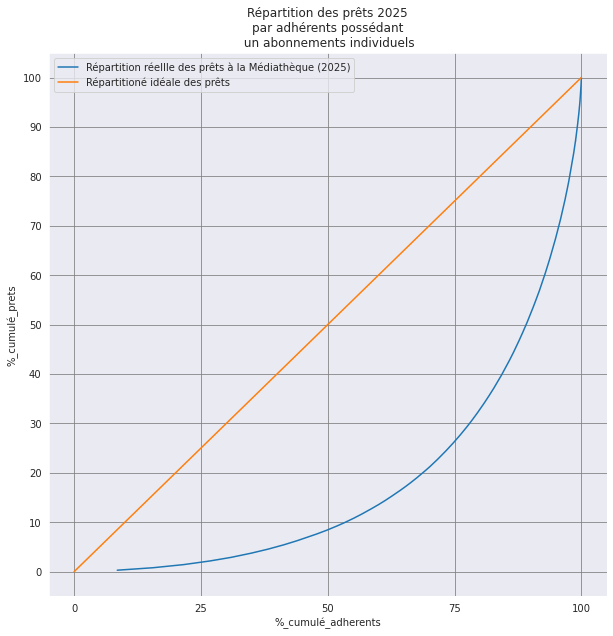

In [226]:
l = 10
h = 10
z = 7
r = list(range(0,101,10))

f,ax = plt.subplots(ncols=1,figsize=(l,h))
ax.grid('y',c='gray')

ax.set_xticks([0,25,50,75,100])
ax.set_yticks(r)
ax.set_title('Répartition des prêts 2025\npar adhérents possédant\n un abonnements individuels')

sns.lineplot(data=prets_reset,x='%_cumulé_adherents',
             y='%_cumulé_prets',
             markers="s",markersize=15,
             label="Répartition réellle des prêts à la Médiathèque (2025)",
            )

sns.lineplot(data=lorenz,x=lorenz.index,y='lorenz',ax=ax,label="Répartitioné idéale des prêts")

#plt.text(x=50+z,y=50,s="Point d'équilibre : 50% des prêts sont réalisés\npar 50% des inscrits",
#         animated=True,backgroundcolor="grey")
plt.show()